## Demo for GMM binning into components
(just for the book)

In [1]:
import pandas as pd
import joblib
import numpy as np

#import dask.dataframe as ddf

import sample_group_stats as sgstat
from sample_group import SG
import extools as ex

import databox as db
import syn_tree

OK -- read the ontology db (19571, 4)
Restored 303734 tags and 191240 tokens. Run update_corpus_tagdata() to update.
-- loaded the skipgram model tank/fasttext_8.model --


In [2]:
grid=sgstat.GMMScore(SG('Bird#class'),'adaptation_comment')

My URI: Bird#class
My path: data/Bird__class/
My taxons: (226) ['Barn_Owl#species', 'Buff-necked_Ibis#species', 'Common_Crane#species'] ...
Loaded data/Bird__class//pair_df.pkl
ica_tf.pkl restored
=== get_tokendict Restored SG token dictionary data/Bird__class//token_dict.pkl
==make_tokenfeat_df==
==make_tokenfeat_df done==
restored data/Bird__class//gmm_dict.pkl


In [3]:
comp_id = 2



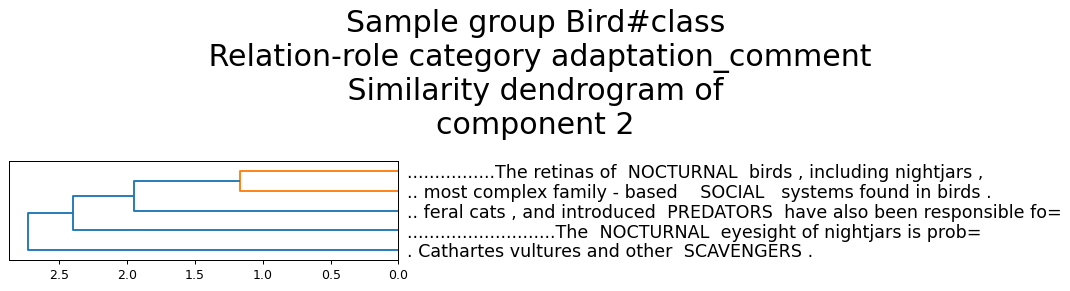

In [4]:
grid.make_dendrogram(comp_id,topN=5)

In [5]:
# TODO
# Make a "window" version of the dendrogram if possible 
# (it is, see https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html)

BayesianGaussianMixture(n_components=8, random_state=42)

In [7]:
# Get the X's cluster ids

grid.idata
xc = grid.gmm.predict(grid.idata)
xc

array([0, 0, 2, 0, 4, 5, 4, 1, 2, 0, 0, 1, 2, 4, 0, 7, 0, 6, 0, 3, 0, 0,
       7, 0, 0, 5, 6, 5, 2, 2, 4, 4, 7, 7, 3, 7, 0, 6, 2, 4, 2, 1, 1, 2,
       2, 7, 5, 2, 6, 2, 2, 1, 2, 7, 0, 4, 7, 0, 0, 4, 0, 6, 2, 5, 2, 2,
       4, 2, 2, 6, 1, 2, 7, 1, 2, 0, 2, 0, 4, 0, 0, 2, 7, 1, 6, 2, 3, 4,
       7, 0, 2, 5, 4, 7, 4, 0, 0, 2, 2, 6, 2, 2, 6, 7, 1, 1, 2, 2, 2, 1,
       6, 4, 4, 2, 4, 0, 0, 0, 0, 2, 2, 0, 1, 2, 6, 1, 1, 0, 2, 0, 2, 1,
       2, 7, 2, 2, 0, 1, 4, 1, 5, 1, 3, 2, 4, 0, 0, 0, 0, 2, 2, 0, 2, 4,
       1, 0, 0, 3, 3, 3, 7, 2, 1, 2, 2, 7, 0, 2, 7, 1, 4, 7, 0, 6, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 7, 1, 1, 1, 1, 2, 1, 4, 5, 2, 7, 1,
       4, 4, 1, 7, 2, 2, 2, 2, 2, 0, 1, 0, 7, 0])

In [8]:
grid.sg.group_name

'Bird__class'

mean:[1.39 0.3 ]
mean:[ 0.34 -0.64]
mean:[-0.51  0.61]
mean:[3.12 0.28]
mean:[ 0.85 -0.12]
mean:[-1.77  0.14]
mean:[-1.1  -0.35]
mean:[-0.58  0.27]


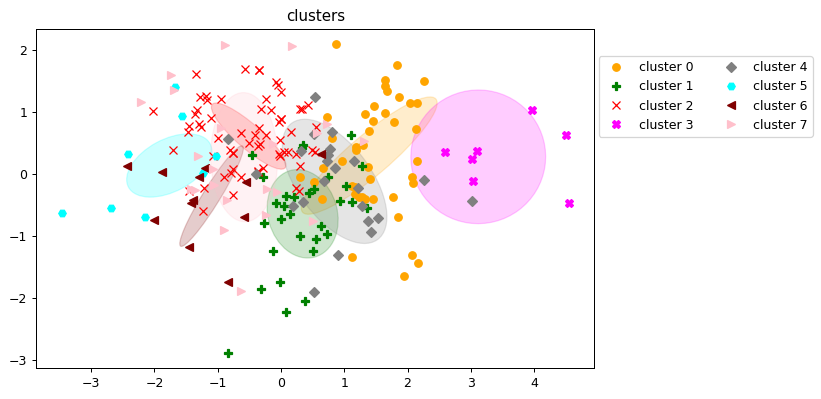

In [9]:
from matplotlib import figure, pyplot as plt
import matplotlib as mpl

fig = figure.Figure(figsize=(8,5),dpi=90)
fig.tight_layout(pad=5.0)

axs = fig.subplots(1,1,sharey=False)
ax = axs


legends = []
ells = []

markers = 'oPxXDH<>'
colors = ['orange','green','red','magenta','gray','cyan','maroon','pink']



for ci in range(grid.gmm.n_components):
    
    x = np.array(grid.idata[xc == ci])[:,[0,1]]    
    ax.plot(x[:,0],x[:,1],markers[ci],color=colors[ci])
    legends.append('cluster %d'%ci)
    
    means = grid.gmm.means_[ci,[0,1]]
    covariances = grid.gmm.covariances_[ci]

    v, w = np.linalg.eigh(covariances) 

    #print("axis:%s"%str(np.round(w[-1],2)))
    print("mean:%s"%str(np.round(means,2)))

    u = w[-1] # normed vector
    angle = np.arctan2(u[1], u[0])
    angle = 180 + (180 * angle / np.pi)  # pc1 angle in degrees
    
    pc1 = w[-1] * np.sqrt(v[-1]) # pr comp1
    pc2 = w[-2] * np.sqrt(v[-2]) # pr comp2
    
    axis_a = 2.8 * np.linalg.norm(pc1[[0,1]])
    axis_b = 2.8 * np.linalg.norm(pc2[[0,1]])

    p=['purple','cyan','yellow','red']

    ell = mpl.patches.Ellipse(
               (means[0],means[1]), axis_a, axis_b, angle=angle, color=colors[ci]
           )
    ell.set_clip_box(ax.bbox)
    ell.set_alpha(0.2)
    ells.append(ell)

for ell in ells:
    ax.add_artist(ell)


ax.set_title("clusters")
ax.legend(legends,loc='center', bbox_to_anchor=(1.2, .8),
          ncol=2, fancybox=True)

fig

In [10]:
grid.compute_feature_prediction()
grid.compute_entropy()

=== compute_entropy Bird__class adaptation_comment ===
=== compute_entropy done ===


In [11]:
pwe = grid.clust_pw_entropy[[0,2,4]]
pwe.loc[pwe.max(axis=1).sort_values().index[:-10:-1]].round(3)

,0,2,4
feat,,,
nmod>case> of,0.014,0.000,0.069
amod< ...,0.000,0.067,0.000
nmod> ...,0.006,0.000,0.054
amod<det> the,0.000,0.040,0.000
nsubj< include,0.038,0.000,-0.003
obj<obl>amod> ...,0.000,-0.000,0.035
nmod> owl,-0.002,0.000,0.034
amod> ...,0.032,-0.011,-0.004
obj<obl> ...,-0.001,-0.001,0.032


In [12]:
xx=[]
for coli in pwe.columns:
    topi = pwe[coli].sort_values(ascending=False).head(10).reset_index()
    x = topi.feat + ' *** ' +  topi[coli].round(3).astype(str)+''
    x.name='cluster_%d'%coli
    xx.append(x)
xx=pd.concat(xx,axis=1)
xx['rank']=list(range(1,len(xx)+1))
xx.set_index('rank',inplace=True)

xx.to_csv('plots/bird_ada-com-clustdiv.csv')
xx


,cluster_0,cluster_2,cluster_4
rank,,,
1,nsubj< include *** 0.038,amod< ... *** 0.067,nmod>case> of *** 0.069
2,amod> ... *** 0.032,amod<det> the *** 0.04,nmod> ... *** 0.054
3,nsubj<obj> ... *** 0.031,amod<amod> ... *** 0.031,obj<obl>amod> ... *** 0.035
4,nsubj<conj>cc> and *** 0.029,amod<nmod> ... *** 0.029,nmod> owl *** 0.034
5,nsubj<cop> be *** 0.027,amod<obl< ... *** 0.027,obj<obl> ... *** 0.032
6,nsubj<conj> ... *** 0.026,amod<det> a *** 0.027,obj<obl>det> the *** 0.031
7,obj<advcl<conj> ... *** 0.026,amod<nmod>case> of *** 0.027,appos> ... *** 0.031
8,nsubj<obj>conj> ... *** 0.026,amod<nsubj< ... *** 0.027,obj<obl>case> ... *** 0.027
9,nsubj< ... *** 0.021,cc> and *** 0.024,nmod>amod> eared *** 0.023


In [13]:
ex_featD=pwe.loc[pwe.max(axis=1).sort_values(ascending=False).head(8).index].round(3)
ex_featD

,0,2,4
feat,,,
nmod>case> of,0.014,0.000,0.069
amod< ...,0.000,0.067,0.000
nmod> ...,0.006,0.000,0.054
amod<det> the,0.000,0.040,0.000
nsubj< include,0.038,0.000,-0.003
obj<obl>amod> ...,0.000,-0.000,0.035
nmod> owl,-0.002,0.000,0.034
amod> ...,0.032,-0.011,-0.004


In [14]:
ex_feat_arr = grid.feat_compvec_df.loc[ex_featD.index][[0,1]]
ex_feat_arr.columns=['x','y']
ex_feat_arr




,x,y
feat,,
nmod>case> of,0.458394,-0.240927
amod< ...,-0.190451,0.191778
nmod> ...,0.039889,0.067541
amod<det> the,0.118249,0.449350
nsubj< include,0.524240,-0.019675
obj<obl>amod> ...,-0.244178,0.093634
nmod> owl,0.002182,0.033441
amod> ...,0.688854,0.298564


mean:[1.39 0.3 ]
mean:[ 0.34 -0.64]
mean:[-0.51  0.61]
mean:[3.12 0.28]
mean:[ 0.85 -0.12]
mean:[-1.77  0.14]
mean:[-1.1  -0.35]
mean:[-0.58  0.27]


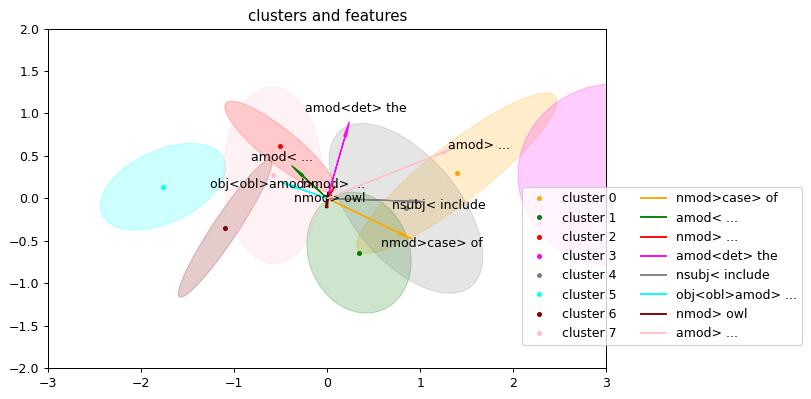

In [15]:

from matplotlib import figure, pyplot as plt
import matplotlib as mpl

fig = figure.Figure(figsize=(8,5),dpi=90)
fig.tight_layout(pad=5.0)

axs = fig.subplots(1,1,sharey=False)
ax = axs


legends = []
ells = []

markers = 'oPxXDH<>'
colors = ['orange','green','red','magenta','gray','cyan','maroon','pink','brown','purple']



for ci in range(grid.gmm.n_components):
    
    x = np.array(grid.idata[xc == ci])[:,[0,1]]    
    legends.append('cluster %d'%ci)
    
    means = grid.gmm.means_[ci,[0,1]]
    covariances = grid.gmm.covariances_[ci]

    ax.plot(means[0],means[1],'.',color=colors[ci])
    
    v, w = np.linalg.eigh(covariances) 

    #print("axis:%s"%str(np.round(w[-1],2)))
    print("mean:%s"%str(np.round(means,2)))

    u = w[-1] # normed vector
    angle = np.arctan2(u[1], u[0])
    angle = 180 + (180 * angle / np.pi)  # pc1 angle in degrees
    
    pc1 = w[-1] * np.sqrt(v[-1]) # pr comp1
    pc2 = w[-2] * np.sqrt(v[-2]) # pr comp2
    
    axis_a = 2.8 * np.linalg.norm(pc1[[0,1]])
    axis_b = 2.8 * np.linalg.norm(pc2[[0,1]])

    p=['purple','cyan','yellow','red']

    ell = mpl.patches.Ellipse(
               (means[0],means[1]), axis_a, axis_b, angle=angle, color=colors[ci]
           )
    ell.set_clip_box(ax.bbox)
    ell.set_alpha(0.2)
    ells.append(ell)


coli = 0
for arr in list(ex_feat_arr.index):
    (x,y) = ex_feat_arr.loc[arr] * 2
    ax.annotate('',(x,y),xytext=(0,0),arrowprops={'width':0.02,'headwidth':2,'color':colors[coli]})
    legends.append(arr)
    ax.text(1.2*x-0.04*len(arr),1.2*y-0.02*coli,arr,fontsize=10)
    ax.plot(x,y,'-',color=colors[coli])
    coli += 1
    
    


ax.legend(legends,loc='center', bbox_to_anchor=(1.1,.3),
          ncol=2, fancybox=True)

for ell in ells:
    ax.add_artist(ell)
    
ax.set_title("clusters and features")
ax.set_xlim([-3, 3])
ax.set_ylim([-2, 2])
fig



In [16]:
# TODO Let's make a nice function version of both plots (features on and off)

In [21]:
ex.pretty_token('Eur-3ec7_370_territorial-11').ctx

['At 250– 350 Hz , the Eurasian eagle - owls',
 '[territorial]',
 'song or call is deeper , farther - carrying and']

In [23]:
ap_ex = sgstat.explain_arcpath('compound>amod>',grid.sg,20)

... by " ant - **FOLLOWING** "    BIRDS    such as antbirds and woodcree=
...... the **EXTANT** families TROCHILIDAE  hummingbirds ) , Hemiprocnid=
............A **THIRD** - year     BIRD    will also exhibit a small zon=
..It is a **COASTAL** breeding     BIRD    around the north Pacific and =
....... garden and countryside    BIRDS    have beaks specialised for ea=
.................**OLD** World   PIGEONS   are natives of Europe , Asia =
......This **SMALL** passerine     BIRD    is found in short dense veget=
................**GREAT** grey     OWL     : Threats .                   
................**GREAT** grey     OWL     : Habitat .                   
................**GREAT** grey     OWL     : Range .                     
. **FRESH** - and salt - water   WETLANDS  , including parks , small pon=
............**SOUTHERN** storm   PETRELS    Oceanitidae ) are found in a=
....... trans - **EQUATORIAL**  MIGRATIONS , including the Wilson 's sto=
 are long or **SHORT** - range  MIGRAT

In [29]:
ap_ex[0][0]

'Ant-938d_372_birds-22'

In [30]:
ex.pretty_token('Ant-938d_372_birds-22').t_synt

,form,arcpath
widx,,
12,ant,conj<advmod>
13,most,conj<advmod>advmod>
14,commonly,conj<advmod>
15,attended,conj<
16,by,compound>case>
17,"""",
18,ant,compound>
19,-,
20,following,compound>amod>
